<a href="https://colab.research.google.com/github/demsaid400-cpu/DI_BOOTCAMP/blob/main/ExercicesXP_1_to_10_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import seaborn as sns

titanic = sns.load_dataset('titanic')

rows_before = len(titanic)

duplicates = titanic.duplicated()

num_duplicates = duplicates.sum()

print("Nombre de doublons trouvés :", num_duplicates)

titanic_clean = titanic.drop_duplicates()

rows_after = len(titanic_clean)

print("Nombre de lignes avant suppression :", rows_before)
print("Nombre de lignes après suppression :", rows_after)
print("Nombre de lignes supprimées :", rows_before - rows_after)

print("Doublons restants :", titanic_clean.duplicated().sum())
print("\nInformations sur le dataset nettoyé :")
print(titanic_clean.info())

print("\nPremières lignes du dataset nettoyé :")
print(titanic_clean.head())


Nombre de doublons trouvés : 107
Nombre de lignes avant suppression : 891
Nombre de lignes après suppression : 784
Nombre de lignes supprimées : 107
Doublons restants : 0

Informations sur le dataset nettoyé :
<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     784 non-null    int64   
 1   pclass       784 non-null    int64   
 2   sex          784 non-null    object  
 3   age          678 non-null    float64 
 4   sibsp        784 non-null    int64   
 5   parch        784 non-null    int64   
 6   fare         784 non-null    float64 
 7   embarked     782 non-null    object  
 8   class        784 non-null    category
 9   who          784 non-null    object  
 10  adult_male   784 non-null    bool    
 11  deck         202 non-null    category
 12  embark_town  782 non-null    object  
 13  alive        784 non-null    object  
 1

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer

titanic = sns.load_dataset('titanic')

print(titanic.head())

titanic_dropna = titanic.dropna()

print("Dimensions avant suppression :", titanic.shape)
print("Dimensions après suppression :", titanic_dropna.shape)

titanic_mean = titanic.copy()

titanic_mean['age'] = titanic_mean['age'].fillna(
    titanic_mean['age'].mean()
)

print("Valeurs manquantes dans age :")
print(titanic_mean['age'].isnull().sum())

titanic_imputer = titanic.copy()

imputer = SimpleImputer(strategy='median')

titanic_imputer[['age']] = imputer.fit_transform(
    titanic_imputer[['age']]
)

print("Valeurs manquantes dans age :")
print(titanic_imputer['age'].isnull().sum())

titanic_constant = titanic.copy()

titanic_constant['deck'] = titanic_constant['deck'].cat.add_categories('Unknown')
titanic_constant['deck'] = titanic_constant['deck'].fillna('Unknown')

titanic_constant['embark_town'] = titanic_constant['embark_town'].fillna('Unknown')

print(titanic_constant[['deck', 'embark_town']].isnull().sum())


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
Dimensions avant suppression : (891, 15)
Dimensions après suppression : (182, 15)
Valeurs manquantes dans age :
0
Valeurs manquantes dans age :
0
deck           0
embark_town    0
dtype: int64


In [ ]:
print("Valeurs manquantes après traitement :\n")

print("Dataset avec moyenne :")
print(titanic_mean.isnull().sum())

print("\nDataset avec constante :")
print(titanic_constant.isnull().sum())

Valeurs manquantes après traitement :

Dataset avec moyenne :
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Dataset avec constante :
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck             0
embark_town      0
alive            0
alone            0
dtype: int64


In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

titanic = sns.load_dataset('titanic')

print("Colonnes disponibles :", titanic.columns.tolist())

titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

print("\nAperçu des colonnes de famille :")
display(titanic[['sibsp', 'parch', 'family_size']].head())


Colonnes disponibles : ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Aperçu des colonnes de famille :


,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

titanic['person_type'] = titanic['who'].replace({
    'man': 'Adult Male',
    'woman': 'Adult Female',
    'child': 'Minor'
})

print("Répartition des types de personnes :")
print(titanic['person_type'].value_counts())

le = LabelEncoder()
titanic['type_encoded'] = le.fit_transform(titanic['person_type'])

print("\nAperçu de l'encodage :")
display(titanic[['person_type', 'type_encoded']].drop_duplicates())


Répartition des types de personnes :
person_type
Adult Male      537
Adult Female    271
Minor            83
Name: count, dtype: int64

Aperçu de l'encodage :


,person_type,type_encoded
0,Adult Male,1
1,Adult Female,0
7,Minor,2


In [ ]:
titanic_encoded = pd.get_dummies(
    titanic,
    columns=['sex', 'embarked'],
    drop_first=True
)

titanic_encoded.head()
print("Colonnes ajoutées :")
print(['family_size', 'title', 'title_encoded'])

print("\nAperçu final du dataset :")
print(titanic_encoded.head())
titanic_encoded.columns

Colonnes ajoutées :
['family_size', 'title', 'title_encoded']

Aperçu final du dataset :
   survived  pclass   age  sibsp  parch     fare  class    who  adult_male  \
0         0       3  22.0      1      0   7.2500  Third    man        True   
1         1       1  38.0      1      0  71.2833  First  woman       False   
2         1       3  26.0      0      0   7.9250  Third  woman       False   
3         1       1  35.0      1      0  53.1000  First  woman       False   
4         0       3  35.0      0      0   8.0500  Third    man        True   

  deck  embark_town alive  alone  family_size   person_type  type_encoded  \
0  NaN  Southampton    no  False            2    Adult Male             1   
1    C    Cherbourg   yes  False            2  Adult Female             0   
2  NaN  Southampton   yes   True            1  Adult Female             0   
3    C  Southampton   yes  False            2  Adult Female             0   
4  NaN  Southampton    no   True            1    Adult Ma

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'class', 'who',
       'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'family_size',
       'person_type', 'type_encoded', 'sex_male', 'embarked_Q', 'embarked_S'],
      dtype='object')

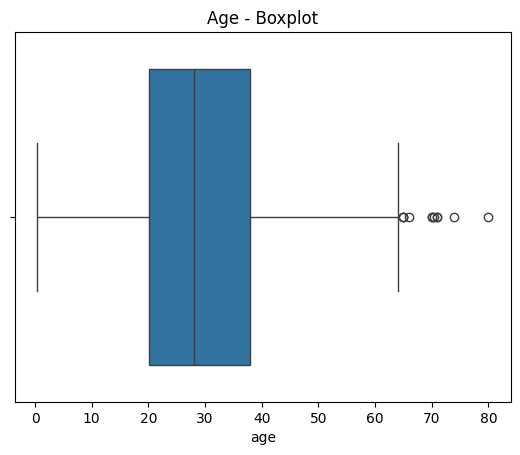

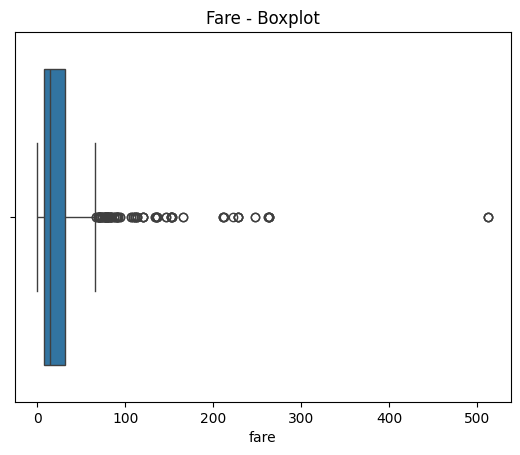

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
titanic = sns.load_dataset('titanic')

titanic[['age', 'fare']].describe()
plt.figure()
sns.boxplot(x=titanic['age'])
plt.title("Age - Boxplot")
plt.show()



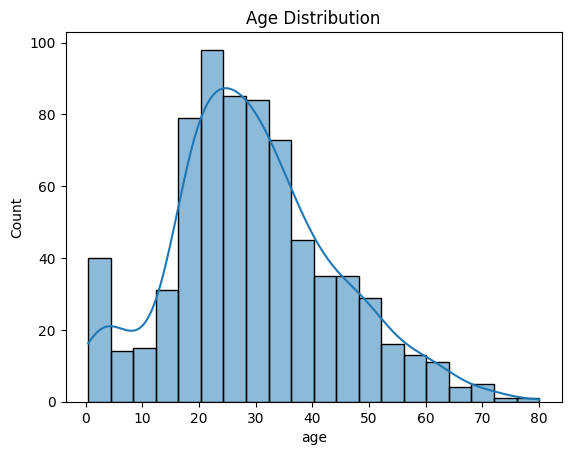

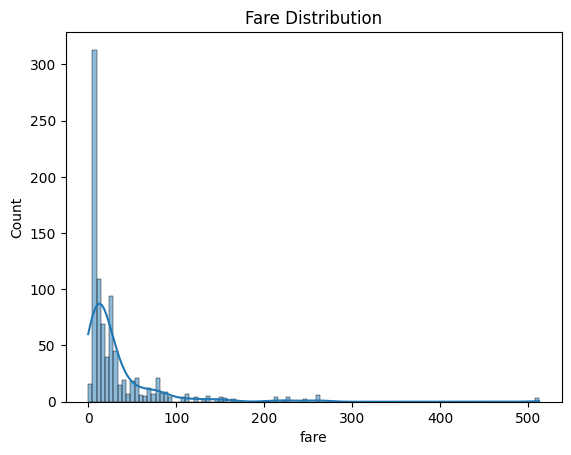

Fare outliers: 116
Age outliers: 11
Shape avant: (891, 15)
Shape après suppression: (603, 15)


In [ ]:
plt.figure()
sns.histplot(titanic['age'], kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure()
sns.histplot(titanic['fare'], kde=True)
plt.title("Fare Distribution")
plt.show()
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] < lower) | (df[column] > upper)], lower, upper

fare_outliers, fare_low, fare_high = detect_outliers_iqr(titanic, 'fare')
age_outliers, age_low, age_high = detect_outliers_iqr(titanic, 'age')

print("Fare outliers:", len(fare_outliers))
print("Age outliers:", len(age_outliers))

titanic_cap = titanic.copy()

fare_cap = titanic_cap['fare'].quantile(0.98)
age_cap = titanic_cap['age'].quantile(0.98)

titanic_cap['fare'] = np.where(
    titanic_cap['fare'] > fare_cap,
    fare_cap,
    titanic_cap['fare']
)
titanic_log = titanic.copy()

titanic_log['fare_log'] = np.log1p(titanic_log['fare'])
titanic_log['age_log'] = np.log1p(titanic_log['age'])
titanic_clean = titanic.copy()

titanic_clean = titanic_clean[
    (titanic_clean['fare'] >= fare_low) &
    (titanic_clean['fare'] <= fare_high) &
    (titanic_clean['age'] >= age_low) &
    (titanic_clean['age'] <= age_high)
]

print("Shape avant:", titanic.shape)
print("Shape après suppression:", titanic_clean.shape)


In [ ]:
print("Avant traitement:")
print(titanic[['age', 'fare']].describe())

print("\nAprès capping:")
print(titanic_cap[['age', 'fare']].describe())

print("\nAprès suppression:")
print(titanic_clean[['age', 'fare']].describe())

Avant traitement:
              age        fare
count  714.000000  891.000000
mean    29.699118   32.204208
std     14.526497   49.693429
min      0.420000    0.000000
25%     20.125000    7.910400
50%     28.000000   14.454200
75%     38.000000   31.000000
max     80.000000  512.329200

Après capping:
              age        fare
count  714.000000  891.000000
mean    29.699118   30.678483
std     14.526497   39.904946
min      0.420000    0.000000
25%     20.125000    7.910400
50%     28.000000   14.454200
75%     38.000000   31.000000
max     80.000000  211.337500

Après suppression:
              age        fare
count  603.000000  603.000000
mean    28.269900   18.608250
std     13.468892   13.654694
min      0.420000    0.000000
25%     20.000000    7.925000
50%     28.000000   13.000000
75%     36.000000   26.250000
max     64.000000   65.000000


In [ ]:
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
titanic = sns.load_dataset('titanic')

titanic.head()
numeric_cols = ['age', 'fare', 'sibsp', 'parch']

titanic_num = titanic[numeric_cols].copy()

titanic_num.describe()



,age,fare,sibsp,parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


In [ ]:
titanic_num = titanic_num.fillna(titanic_num.median())
scaler = StandardScaler()

titanic_standardized = pd.DataFrame(
    scaler.fit_transform(titanic_num),
    columns=numeric_cols
)

display(titanic_standardized.head())


,age,fare,sibsp,parch
0,-0.565736,-0.502445,0.432793,-0.473674
1,0.663861,0.786845,0.432793,-0.473674
2,-0.258337,-0.488854,-0.474545,-0.473674
3,0.433312,0.420730,0.432793,-0.473674
4,0.433312,-0.486337,-0.474545,-0.473674


Original data:
              age        fare       sibsp       parch
count  891.000000  891.000000  891.000000  891.000000
mean    29.361582   32.204208    0.523008    0.381594
std     13.019697   49.693429    1.102743    0.806057
min      0.420000    0.000000    0.000000    0.000000
25%     22.000000    7.910400    0.000000    0.000000
50%     28.000000   14.454200    0.000000    0.000000
75%     35.000000   31.000000    1.000000    0.000000
max     80.000000  512.329200    8.000000    6.000000

Standardized data (mean ≈ 0, std ≈ 1):
                age          fare         sibsp         parch
count  8.910000e+02  8.910000e+02  8.910000e+02  8.910000e+02
mean   2.272780e-16  3.987333e-18  4.386066e-17  5.382900e-17
std    1.000562e+00  1.000562e+00  1.000562e+00  1.000562e+00
min   -2.224156e+00 -6.484217e-01 -4.745452e-01 -4.736736e-01
25%   -5.657365e-01 -4.891482e-01 -4.745452e-01 -4.736736e-01
50%   -1.046374e-01 -3.573909e-01 -4.745452e-01 -4.736736e-01
75%    4.333115e-01 -2.42

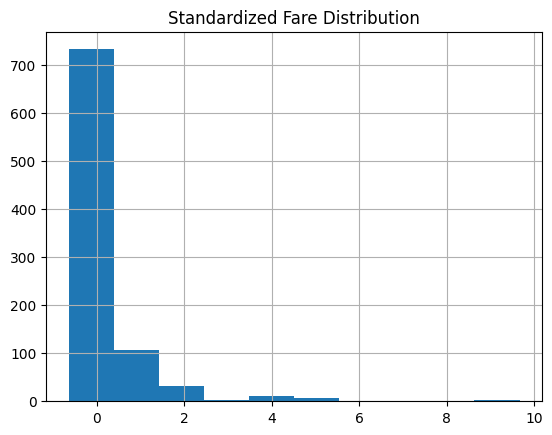

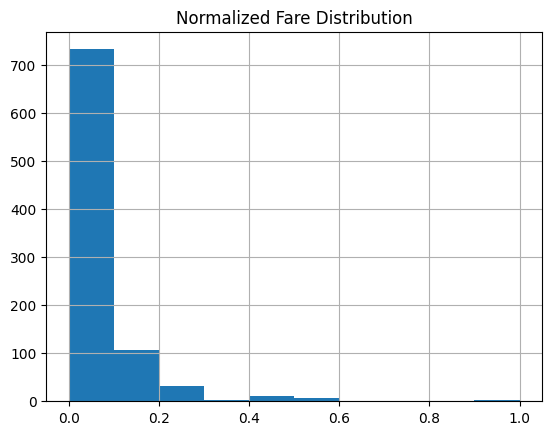

In [ ]:
minmax = MinMaxScaler()

titanic_normalized = pd.DataFrame(
    minmax.fit_transform(titanic_num),
    columns=numeric_cols
)

titanic_normalized.head()
print("Original data:")
print(titanic_num.describe())

print("\nStandardized data (mean ≈ 0, std ≈ 1):")
print(titanic_standardized.describe())

print("\nNormalized data (range 0–1):")
print(titanic_normalized.describe())
import matplotlib.pyplot as plt

plt.figure()
titanic_standardized['fare'].hist()
plt.title("Standardized Fare Distribution")
plt.show()

plt.figure()
titanic_normalized['fare'].hist()
plt.title("Normalized Fare Distribution")
plt.show()

In [49]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
titanic = sns.load_dataset('titanic')

titanic.head()
cat_cols = titanic.select_dtypes(include=['object', 'category']).columns

print("Colonnes catégorielles :")
print(cat_cols)
print(titanic[cat_cols].isnull().sum())
titanic['embarked'] = titanic['embarked'].fillna('Unknown')
titanic['embark_town'] = titanic['embark_town'].fillna('Unknown')

titanic['deck'] = titanic['deck'].cat.add_categories('Unknown')
titanic['deck'] = titanic['deck'].fillna('Unknown')

titanic_encoded = pd.get_dummies(
    titanic,
    columns=['sex', 'embarked', 'embark_town'],
    drop_first=True
)

if 'name' in titanic_encoded.columns:
    titanic_encoded['title'] = titanic_encoded['name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    titanic_encoded['title'] = titanic_encoded['title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
    titanic_encoded['title'] = titanic_encoded['title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
    le = LabelEncoder()
    titanic_encoded['title_encoded'] = le.fit_transform(titanic_encoded['title'])
else:
    print("\nLa colonne 'name' est absente. Utilisation de la colonne 'who' pour l'encodage.")
    le = LabelEncoder()
    titanic_encoded['who_encoded'] = le.fit_transform(titanic_encoded['who'])

titanic_encoded.head()

print("Shape final :", titanic_final.shape)

print("\nColonnes finales :")
print(titanic_final.columns)


Colonnes catégorielles :
Index(['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive'], dtype='object')
sex              0
embarked         2
class            0
who              0
deck           688
embark_town      2
alive            0
dtype: int64

La colonne 'name' est absente. Utilisation de la colonne 'who' pour l'encodage.
Shape final : (891, 20)

Colonnes finales :
Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'class', 'who',
       'adult_male', 'deck', 'alive', 'alone', 'sex_male', 'embarked_Q',
       'embarked_S', 'embarked_Unknown', 'embark_town_Queenstown',
       'embark_town_Southampton', 'embark_town_Unknown', 'who_encoded'],
      dtype='object')


In [57]:

cols_to_drop = ['name', 'title']

existing_cols_to_drop = [c for c in cols_to_drop if c in titanic_encoded.columns]

titanic_final = titanic_encoded.drop(columns=existing_cols_to_drop)

titanic_final.head()
print("Shape final :", titanic_final.shape)

print("\nColonnes finales :")
print(titanic_final.columns)
import pandas as pd
import seaborn as sns
titanic = sns.load_dataset('titanic')

titanic[['age']].head()

bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']

titanic['age_group'] = pd.cut(
    titanic['age'],
    bins=bins,
    labels=labels
)

titanic[['age', 'age_group']].head(10)
titanic['age_group'].value_counts()
titanic_encoded = pd.get_dummies(
    titanic,
    columns=['age_group'],
    drop_first=False
)

titanic_encoded[['age', 'age_group_Child', 'age_group_Teen', 'age_group_Adult', 'age_group_Senior']].head()
print("Shape du dataset :", titanic_encoded.shape)

print("\nColonnes liées à l'âge :")
print([col for col in titanic_encoded.columns if "age" in col])

Shape final : (891, 19)

Colonnes finales :
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'age_group_Child', 'age_group_Teen',
       'age_group_Adult', 'age_group_Senior'],
      dtype='object')
Shape du dataset : (891, 19)

Colonnes liées à l'âge :
['age', 'age_group_Child', 'age_group_Teen', 'age_group_Adult', 'age_group_Senior']
